In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print ("Libraries imported successfully")

Libraries imported successfully


In [2]:
np.random.seed(42)

data = pd.DataFrame({
    "login_count": np.random.randint(1,10,100),
    "file_access_count": np.random.randint(5,50,100),
    "failed_logins": np.random.randint(0,3,100),
    "data_download_MB": np.random.randint(10,500,100)
    })
data.loc[95:]=[25,300,10,4000]
data.head()

,login_count,file_access_count,failed_logins,data_download_MB
0,7,39,2,55
1,4,41,0,382
2,8,18,0,15
3,5,7,2,108
4,7,5,1,389


In [3]:
# Selecting feature columns

features = data[[
    "login_count",
    "file_access_count",
    "failed_logins",
    "data_download_MB"
]]

In [4]:
X = features.values
print("Shape of feature matrix:",X.shape)

Shape of feature matrix: (100, 4)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("First 5 scaled rows:\n", X_scaled[:5])

First 5 scaled rows:
 [[ 0.12848815 -0.04161506  0.25432119 -0.4733717 ]
 [-0.47380007 -0.00871778 -0.68760913 -0.07781668]
 [ 0.3292509  -0.38703647 -0.68760913 -0.52175764]
 [-0.27303733 -0.56797149  0.25432119 -0.40926034]
 [ 0.12848815 -0.60086877 -0.21664397 -0.06934914]]


In [6]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)
#Train model
model.fit(X_scaled)

#predict anomalies
predictions = model.predict(X_scaled)

#Add predictions 
data["anomaly"]=predictions

#See sucspicious employees
data[data["anomaly"] == -1]

,login_count,file_access_count,failed_logins,data_download_MB,anomaly
95,25,300,10,4000,-1
96,25,300,10,4000,-1
97,25,300,10,4000,-1
98,25,300,10,4000,-1
99,25,300,10,4000,-1


In [7]:
scores = model.decision_function(X_scaled)

data["anomaly_score"] = scores

data.head()

,login_count,file_access_count,failed_logins,data_download_MB,anomaly,anomaly_score
0,7,39,2,55,1,0.099706
1,4,41,0,382,1,0.117868
2,8,18,0,15,1,0.031452
3,5,7,2,108,1,0.089298
4,7,5,1,389,1,0.087413


In [8]:
data.sort_values("anomaly_score").head(10)

,login_count,file_access_count,failed_logins,data_download_MB,anomaly,anomaly_score
96,25,300,10,4000,-1,-0.161155
97,25,300,10,4000,-1,-0.161155
98,25,300,10,4000,-1,-0.161155
99,25,300,10,4000,-1,-0.161155
95,25,300,10,4000,-1,-0.161155
82,1,5,2,456,1,0.008482
62,8,48,0,22,1,0.015031
20,1,34,0,480,1,0.023398
2,8,18,0,15,1,0.031452
68,9,45,2,29,1,0.032705


In [9]:
# Create risk levels based on anomaly score

data["risk_level"] = pd.qcut(
    data["anomaly_score"],
    q=3,
    labels=["High Risk", "Medium Risk", "Low Risk"]
)

data.head()

,login_count,file_access_count,failed_logins,data_download_MB,anomaly,anomaly_score,risk_level
0,7,39,2,55,1,0.099706,Medium Risk
1,4,41,0,382,1,0.117868,Low Risk
2,8,18,0,15,1,0.031452,High Risk
3,5,7,2,108,1,0.089298,Medium Risk
4,7,5,1,389,1,0.087413,Medium Risk


In [10]:
#Manual threshold based risk scoring

#calculate percentile thresholds
low_threshold = np.percentile(data["anomaly_score"], 33)
high_threshold = np.percentile(data["anomaly_score"], 66)

print("Low Threshold: ",low_threshold)
print("High Threshold: ",high_threshold)

Low Threshold:  0.07854029631362347
High Threshold:  0.10178037969467812


In [11]:
#Assign risk level manually
def assign_risk(score):
    if score <= low_threshold:
        return "High Risk"
    elif score <= high_threshold:
        return "Medium Risk"
    else:
        return "Low Risk"

data["risk_level"] = data["anomaly_score"].apply(assign_risk)

data.head()

,login_count,file_access_count,failed_logins,data_download_MB,anomaly,anomaly_score,risk_level
0,7,39,2,55,1,0.099706,Medium Risk
1,4,41,0,382,1,0.117868,Low Risk
2,8,18,0,15,1,0.031452,High Risk
3,5,7,2,108,1,0.089298,Medium Risk
4,7,5,1,389,1,0.087413,Medium Risk


In [12]:
#count risk levels
data["risk_level"].value_counts()

risk_level
Low Risk       34
Medium Risk    33
High Risk      33
Name: count, dtype: int64

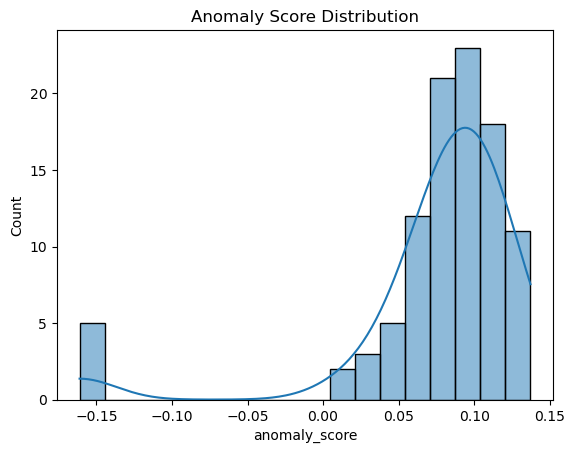

In [13]:
plt.figure()
sns.histplot(data["anomaly_score"], kde=True)
plt.title("Anomaly Score Distribution")
plt.show()

In [14]:
#Timestamp column add

data["login_timestamp"]  = pd.date_range(
    start="2024-01-01",
    periods=len(data),
    freq="H"
)
data.head()

C:\Users\SMRUTI RANJAN NAYAK\AppData\Local\Temp\ipykernel_14936\2423725228.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data["login_timestamp"]  = pd.date_range(


,login_count,file_access_count,failed_logins,data_download_MB,anomaly,anomaly_score,risk_level,login_timestamp
0,7,39,2,55,1,0.099706,Medium Risk,2024-01-01 00:00:00
1,4,41,0,382,1,0.117868,Low Risk,2024-01-01 01:00:00
2,8,18,0,15,1,0.031452,High Risk,2024-01-01 02:00:00
3,5,7,2,108,1,0.089298,Medium Risk,2024-01-01 03:00:00
4,7,5,1,389,1,0.087413,Medium Risk,2024-01-01 04:00:00


In [15]:
#Extract login hours
data["login_hour"] = data["login_timestamp"].dt.hour
data.head()

,login_count,file_access_count,failed_logins,data_download_MB,anomaly,anomaly_score,risk_level,login_timestamp,login_hour
0,7,39,2,55,1,0.099706,Medium Risk,2024-01-01 00:00:00,0
1,4,41,0,382,1,0.117868,Low Risk,2024-01-01 01:00:00,1
2,8,18,0,15,1,0.031452,High Risk,2024-01-01 02:00:00,2
3,5,7,2,108,1,0.089298,Medium Risk,2024-01-01 03:00:00,3
4,7,5,1,389,1,0.087413,Medium Risk,2024-01-01 04:00:00,4


In [16]:
features = data[[
    "login_count",
    "file_access_count",
    "failed_logins",
    "data_download_MB",
    "login_hour"
]]

In [17]:
X = features.values

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
model.fit(X_scaled)
predictions = model.predict(X_scaled)
data["anomaly"] = predictions

In [20]:
# Define working hours (9 AM to 6 PM)

data["after_hours_login"] = data["login_hour"].apply(
    lambda hour: 0 if 9 <= hour <= 18 else 1
)

data[["login_hour", "after_hours_login"]].head()

,login_hour,after_hours_login
0,0,1
1,1,1
2,2,1
3,3,1
4,4,1


In [21]:
features = data[[
    "login_count",
    "file_access_count",
    "failed_logins",
    "data_download_MB",
    "login_hour",
    "after_hours_login"
]]

In [22]:
X = features.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model.fit(X_scaled)

predictions = model.predict(X_scaled)

data["anomaly"] = predictions

In [23]:
#To check after feature add & re-scale & retrain

data["anomaly"].value_counts()

anomaly
 1    95
-1     5
Name: count, dtype: int64

In [24]:
data[data["anomaly"] == -1]

,login_count,file_access_count,failed_logins,data_download_MB,anomaly,anomaly_score,risk_level,login_timestamp,login_hour,after_hours_login
95,25,300,10,4000,-1,-0.161155,High Risk,2024-01-04 23:00:00,23,1
96,25,300,10,4000,-1,-0.161155,High Risk,2024-01-05 00:00:00,0,1
97,25,300,10,4000,-1,-0.161155,High Risk,2024-01-05 01:00:00,1,1
98,25,300,10,4000,-1,-0.161155,High Risk,2024-01-05 02:00:00,2,1
99,25,300,10,4000,-1,-0.161155,High Risk,2024-01-05 03:00:00,3,1


In [25]:
#Create ground truth labels
data["true_label"]= 1
data.loc[95 :,"true_label"]=-1
data.head()

,login_count,file_access_count,failed_logins,data_download_MB,anomaly,anomaly_score,risk_level,login_timestamp,login_hour,after_hours_login,true_label
0,7,39,2,55,1,0.099706,Medium Risk,2024-01-01 00:00:00,0,1,1
1,4,41,0,382,1,0.117868,Low Risk,2024-01-01 01:00:00,1,1,1
2,8,18,0,15,1,0.031452,High Risk,2024-01-01 02:00:00,2,1,1
3,5,7,2,108,1,0.089298,Medium Risk,2024-01-01 03:00:00,3,1,1
4,7,5,1,389,1,0.087413,Medium Risk,2024-01-01 04:00:00,4,1,1


In [26]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(data["true_label"], data["anomaly"])
print("Confusion Matrix: ")
print(cm)

Confusion Matrix: 
[[ 5  0]
 [ 0 95]]


In [27]:
from sklearn.metrics import classification_report

print(classification_report(data["true_label"], data["anomaly"]))

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        95

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



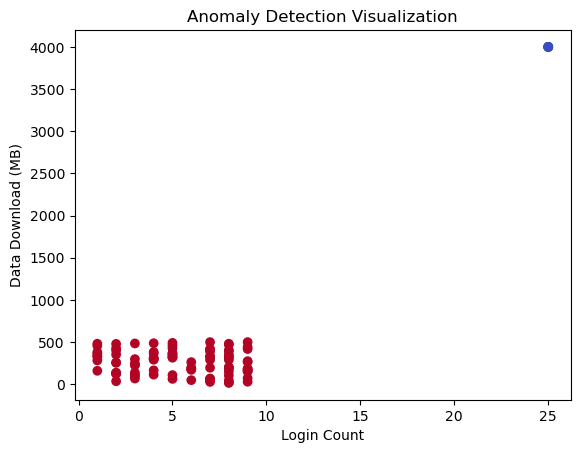

In [28]:
plt.figure()

plt.scatter(
    data["login_count"], 
    data["data_download_MB"], 
    c=data["anomaly"], 
    cmap="coolwarm"
)

plt.xlabel("Login Count")
plt.ylabel("Data Download (MB)")
plt.title("Anomaly Detection Visualization")

plt.show()

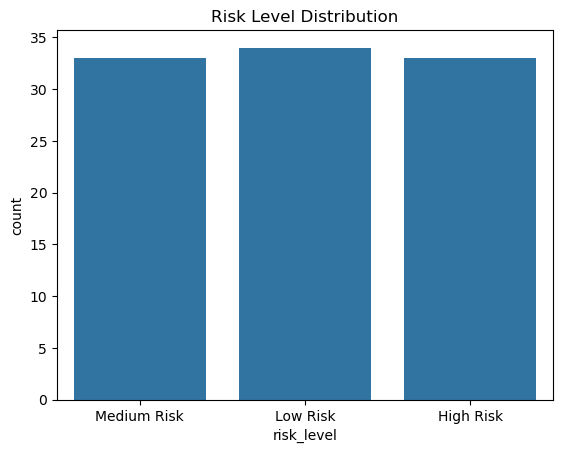

In [29]:
sns.countplot(x=data["risk_level"])
plt.title("Risk Level Distribution")
plt.show()

In [30]:
high_risk_users = data[data["risk_level"] == "High Risk"]

high_risk_users

,login_count,file_access_count,failed_logins,data_download_MB,anomaly,anomaly_score,risk_level,login_timestamp,login_hour,after_hours_login,true_label
2,8,18,0,15,1,0.031452,High Risk,2024-01-01 02:00:00,2,1,1
5,3,9,0,242,1,0.052315,High Risk,2024-01-01 05:00:00,5,1,1
15,2,17,0,125,1,0.072680,High Risk,2024-01-01 15:00:00,15,0,1
20,1,34,0,480,1,0.023398,High Risk,2024-01-01 20:00:00,20,1,1
23,1,43,2,332,1,0.062660,High Risk,2024-01-01 23:00:00,23,1,1
24,3,49,2,137,1,0.073290,High Risk,2024-01-02 00:00:00,0,1,1
27,9,33,2,499,1,0.041424,High Risk,2024-01-02 03:00:00,3,1,1
35,2,46,0,123,1,0.071740,High Risk,2024-01-02 11:00:00,11,0,1
36,4,49,0,297,1,0.069296,High Risk,2024-01-02 12:00:00,12,0,1
37,9,10,2,440,1,0.050919,High Risk,2024-01-02 13:00:00,13,0,1


In [31]:
high_risk_users.to_csv("suspicious_users.csv", index=False)

In [32]:
data.sort_values("anomaly_score").head(5)

,login_count,file_access_count,failed_logins,data_download_MB,anomaly,anomaly_score,risk_level,login_timestamp,login_hour,after_hours_login,true_label
96,25,300,10,4000,-1,-0.161155,High Risk,2024-01-05 00:00:00,0,1,-1
97,25,300,10,4000,-1,-0.161155,High Risk,2024-01-05 01:00:00,1,1,-1
98,25,300,10,4000,-1,-0.161155,High Risk,2024-01-05 02:00:00,2,1,-1
99,25,300,10,4000,-1,-0.161155,High Risk,2024-01-05 03:00:00,3,1,-1
95,25,300,10,4000,-1,-0.161155,High Risk,2024-01-04 23:00:00,23,1,-1
